In [9]:
import pickle
import re
import sqlite3
from pathlib import Path

import missingno as msno
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder




In [10]:

base_path = Path.cwd().parent
print(base_path)
data_path = base_path / "data"
db_file = data_path / "db.sqlite"

# db_file = Path("/content/data/db.sqlite") -- colab

with sqlite3.connect(db_file) as conn:
    df = pd.read_sql_query("SELECT * FROM tabela_glowna", conn)

print("Dataset shape:", df.shape)
print(df.info())
print(df.head())




/
Dataset shape: (4009, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None
      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2  

In [11]:

def clean_price(value):
    if pd.isna(value):
        return None

    value = str(value)
    value = value.replace("$", "")
    value = value.replace(",", "")
    value = value.strip()

    if value == "":
        return None

    return float(value)


def clean_milage(value):
    if pd.isna(value):
        return None

    value = str(value)
    value = value.replace("mi.", "")
    value = value.replace("mi", "")
    value = value.replace(",", "")
    value = value.strip()

    if value == "":
        return None

    return float(value)


def clean_text(value):
    if pd.isna(value):
        return "unknown"

    value = str(value).lower().strip()

    if value == "" or value == "nan":
        return "unknown"

    return value


df["price"] = df["price"].apply(clean_price)
df["milage"] = df["milage"].apply(clean_milage)

text_columns = df.select_dtypes(include=["object"]).columns
for col in text_columns:
    df[col] = df[col].apply(clean_text)

# Usuwamy rekordy bez ceny albo przebiegu, bo to podstawowe dane dla modelu.
df = df.dropna(subset=["price", "milage", "model_year"])

# Braki w kategoriach traktujemy jako osobną kategorię, a nie zgadujemy np. gasoline.
for col in ["fuel_type", "accident", "clean_title"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")
        df[col] = df[col].replace("", "unknown")

# Duplikaty.
df = df.drop_duplicates()




In [12]:

def extract_horsepower(engine):
    if pd.isna(engine):
        return None

    match = re.search(r"(\d+(?:\.\d+)?)\s*hp", str(engine).lower())

    if match is None:
        return None

    return float(match.group(1))


def extract_engine_liters(engine):
    if pd.isna(engine):
        return None

    match = re.search(r"(\d+(?:\.\d+)?)\s*l", str(engine).lower())

    if match is None:
        return None

    return float(match.group(1))


def extract_cylinders(engine):
    if pd.isna(engine):
        return None

    match = re.search(r"v\s?(\d+)|i\s?(\d+)|(\d+)\s*cylinder", str(engine).lower())

    if match is None:
        return None

    for group in match.groups():
        if group is not None:
            return float(group)

    return None


df["engine_hp"] = df["engine"].apply(extract_horsepower)
df["engine_liters"] = df["engine"].apply(extract_engine_liters)
df["engine_cylinders"] = df["engine"].apply(extract_cylinders)

# Wiek samochodu jako cecha często działa lepiej niż sam rocznik.
max_year = int(df["model_year"].max())
df["car_age"] = max_year - df["model_year"]




In [13]:

# Przycinamy ekstremalne ceny, żeby pojedyncze bardzo drogie auta nie rozwalały modelu.
price_low = df["price"].quantile(0.01)
price_high = df["price"].quantile(0.99)
df = df[(df["price"] >= price_low) & (df["price"] <= price_high)]

print("Shape after cleaning:", df.shape)
print(df.isnull().sum())




Shape after cleaning: (3932, 16)
brand                 0
model                 0
model_year            0
milage                0
fuel_type             0
engine                0
transmission          0
ext_col               0
int_col               0
accident              0
clean_title           0
price                 0
engine_hp           777
engine_liters       213
engine_cylinders    423
car_age               0
dtype: int64


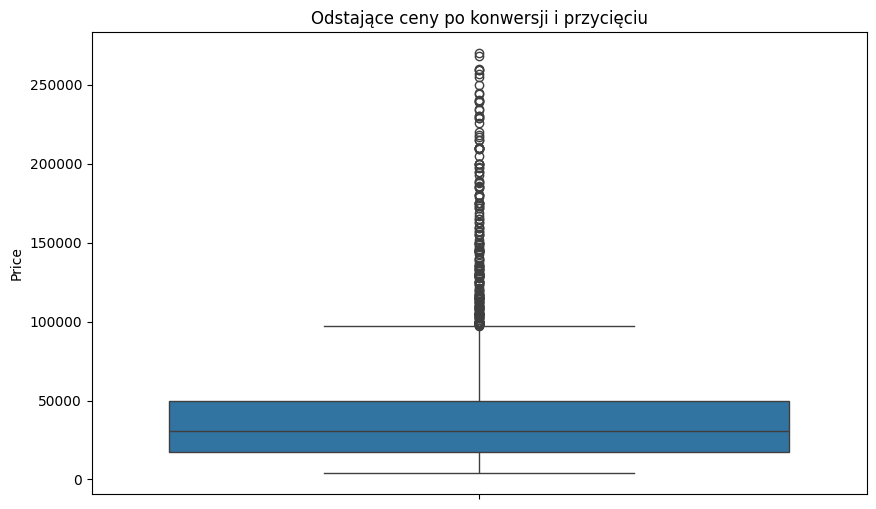

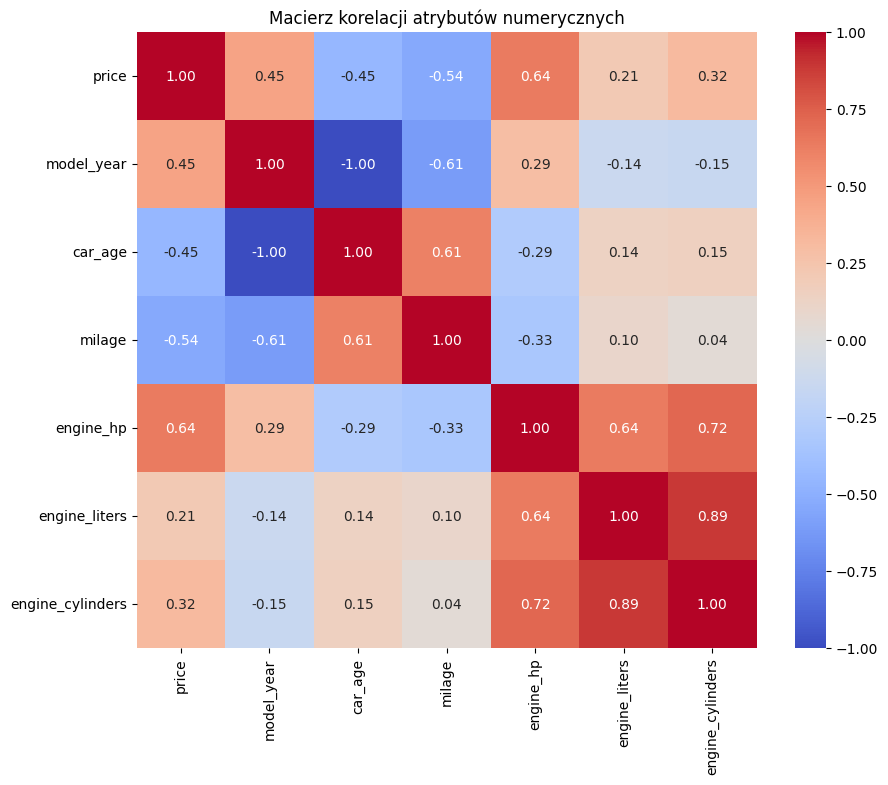

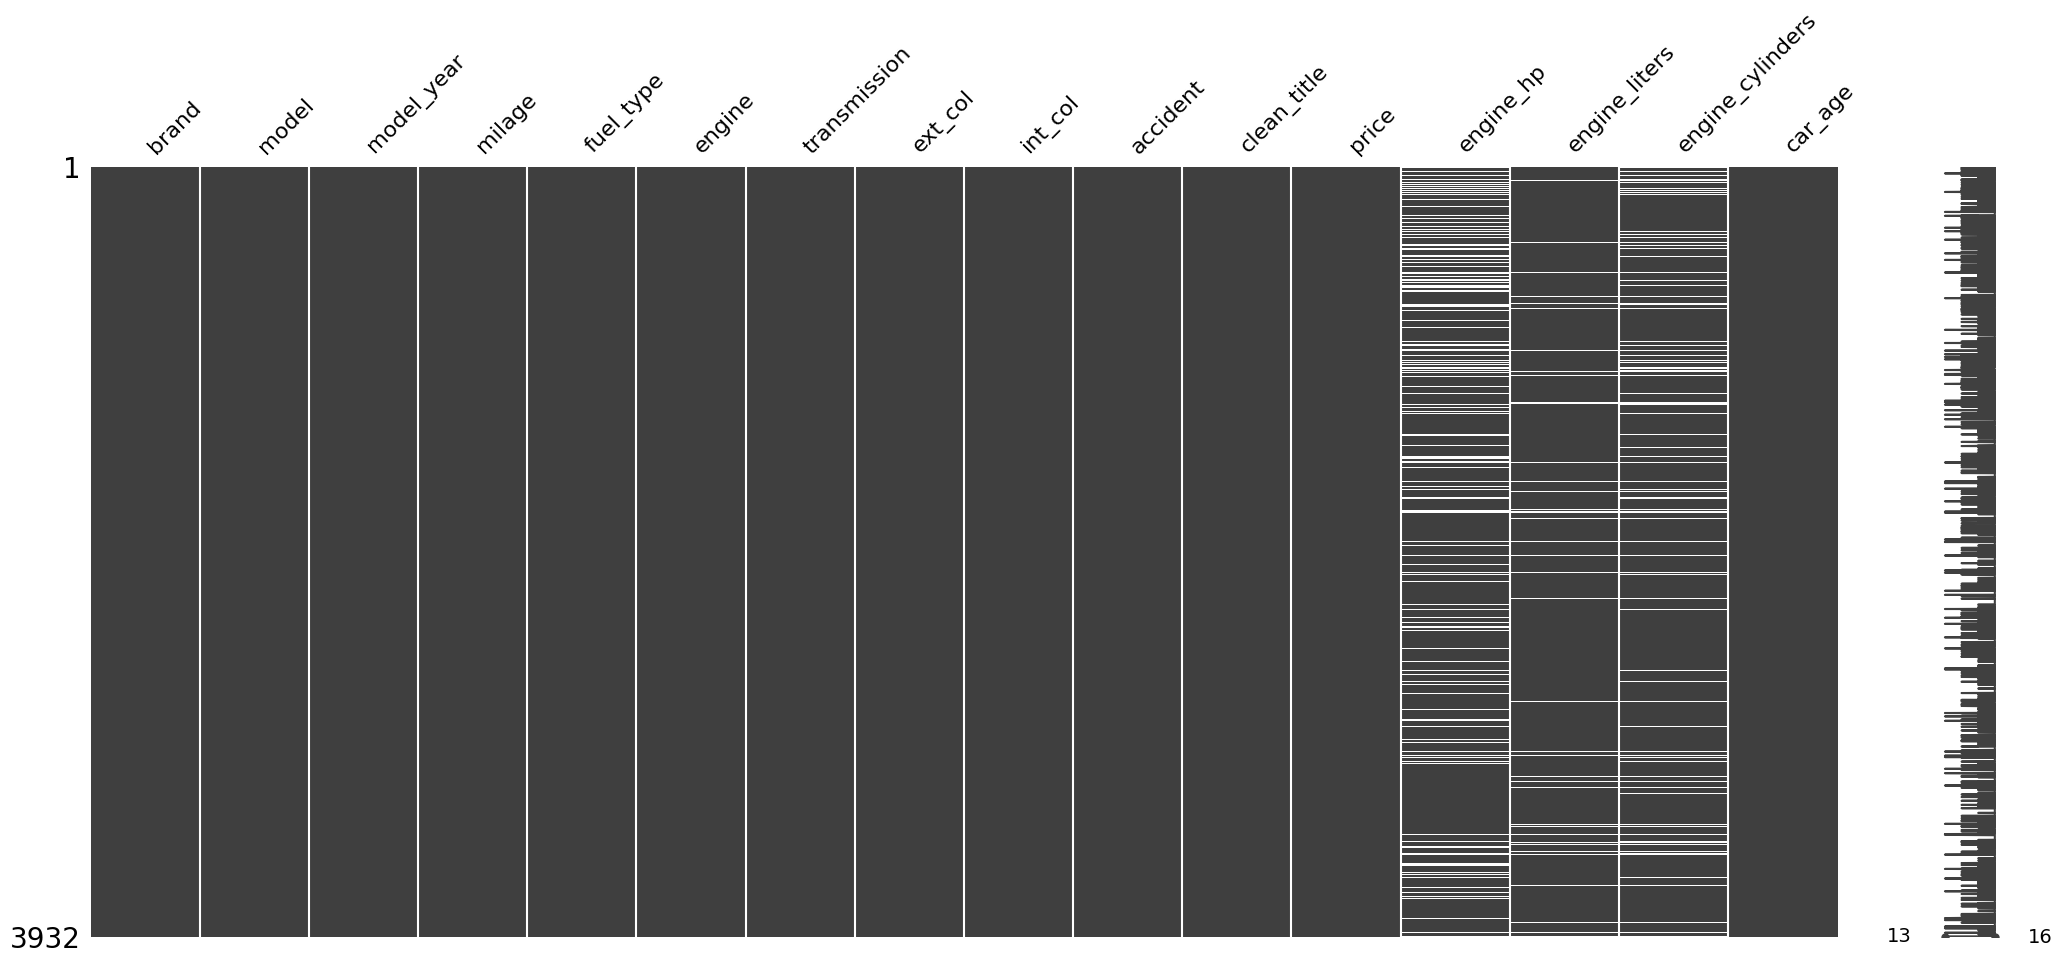

In [14]:

plt.figure(figsize=(10, 6))
sns.boxplot(y=df["price"])
plt.title("Odstające ceny po konwersji i przycięciu")
plt.ylabel("Price")
plt.show()

numeric_df = df[["price", "model_year", "car_age", "milage", "engine_hp", "engine_liters", "engine_cylinders"]]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz korelacji atrybutów numerycznych")
plt.show()

msno.matrix(df)
plt.show()




In [15]:

features = [
    "model_year",
    "car_age",
    "milage",
    "engine_hp",
    "engine_liters",
    "engine_cylinders",
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title",
]

# Bierzemy tylko kolumny, które faktycznie istnieją w danych.
features = [col for col in features if col in df.columns]

X = df[features]
y = df["price"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model),
])




In [16]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

X_test, X_eval, y_test, y_eval = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
)

pipeline.fit(X_train, y_train)


def evaluate_model(name, X_part, y_part):
    predictions = pipeline.predict(X_part)

    mae = mean_absolute_error(y_part, predictions)
    rmse = mean_squared_error(y_part, predictions) ** 0.5
    r2 = r2_score(y_part, predictions)

    print(f"\n{name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.2f}")

    return predictions


y_pred_test = evaluate_model("TEST SET", X_test, y_test)
y_pred_eval = evaluate_model("EVALUATION SET", X_eval, y_eval)





TEST SET
MAE:  8769.71
RMSE: 15761.96
R2:   0.81

EVALUATION SET
MAE:  8536.02
RMSE: 15149.52
R2:   0.81


In [17]:

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

print("\nCross validation R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())





Cross validation R2 scores: [0.77862677 0.78533949 0.77784655 0.81218618 0.83940542]
Mean CV R2: 0.798680882059576



TOP 20 feature importances:
                                                feature  importance
2                                           num__milage    0.399346
3                                        num__engine_hp    0.186624
4                                    num__engine_liters    0.140893
30                               cat__brand_lamborghini    0.032185
0                                       num__model_year    0.031830
1                                          num__car_age    0.031469
45                                   cat__brand_porsche    0.031040
5                                 num__engine_cylinders    0.016094
10                                   cat__brand_bentley    0.014068
2526  cat__transmission_7-speed automatic with auto-...    0.013564
2245        cat__engine_4.0l v8 32v gdi dohc twin turbo    0.010597
39                             cat__brand_mercedes-benz    0.007558
31                                      cat__brand_land    0.005477
2800               

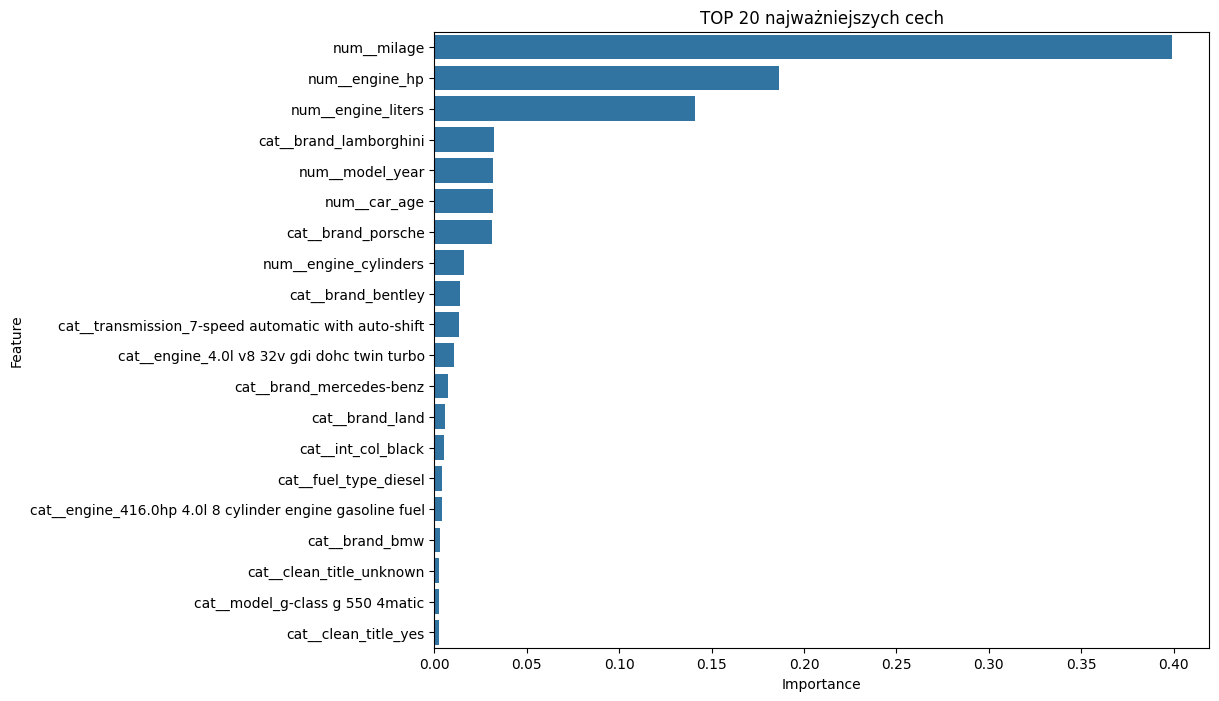

In [18]:

trained_model = pipeline.named_steps["model"]
trained_preprocessor = pipeline.named_steps["preprocessor"]

encoded_feature_names = trained_preprocessor.get_feature_names_out()
importances = trained_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": importances,
}).sort_values(by="importance", ascending=False)

print("\nTOP 20 feature importances:")
print(feature_importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature",
)
plt.title("TOP 20 najważniejszych cech")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()




In [19]:

models_path = base_path / "models"
models_path.mkdir(parents=True, exist_ok=True)

model_file = models_path / "used_car_price_model.pkl"

model_package = {
    "pipeline": pipeline,
    "features": features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "max_year_used_for_car_age": max_year,
}

with open(model_file, "wb") as file:
    pickle.dump(model_package, file)

print(f"\nModel saved to: {model_file}")





Model saved to: /models/used_car_price_model.pkl


In [20]:

with open(model_file, "rb") as file:
    loaded_package = pickle.load(file)

loaded_pipeline = loaded_package["pipeline"]
example_predictions = loaded_pipeline.predict(X_eval.head(5))

print("\nExample predictions:")
print(example_predictions)



Example predictions:
[28184.45881087 31673.32063061 20256.96987026 10336.3554158
 85027.98672955]
